<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [2]:
!pip install yadisk
!pip install numpy scipy scikit-learn causalml matplotlib seaborn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yadisk
import requests

from copy import deepcopy

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

from causalml.inference.tree import UpliftRandomForestClassifier

RANDOM_STATE = 42

In [9]:
y = yadisk.YaDisk()

public_url = "https://disk.yandex.ru/d/g9LzEzOc_O-r1w"

download_link = y.get_public_download_link(public_url)

In [10]:
r = requests.get(download_link)

with open("Data.zip", "wb") as f:
    f.write(r.content)

In [11]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [12]:
aggs = pd.read_csv('AGGS_FINAL.csv')
campaigns = pd.read_csv('CAMPAINGS.csv')
contracts = pd.read_csv('CONTRACTS_FINAL.csv')
pic = pd.read_csv('PEOPLE_IN_CAMPAINGS_FINAL.csv')

In [13]:
contracts = contracts.drop(columns=['Unnamed: 0'])
campaigns = campaigns.drop(columns=['Unnamed: 0'])
pic = pic.drop(columns=['Unnamed: 0'])
aggs = aggs.drop(columns=['Unnamed: 0'])

In [14]:
aggs_1 = aggs.copy()
campaigns_1 = campaigns.copy()
contracts_1 = contracts.copy()
pic_1 = pic.copy()

In [15]:
campaigns_1['product_id'] = campaigns_1['product_id'].astype(str).str.zfill(4)
contracts_1['product_id'] = contracts_1['product_id'].astype(str).str.zfill(4)

contracts_1['contract_date'] = pd.to_datetime(contracts_1['contract_date'], errors='coerce')
pic_1['delivery_date'] = pd.to_datetime(pic_1['delivery_date'], errors='coerce')

In [16]:
campaigns_0001 = campaigns_1[campaigns_1['product_id'] == '0001'].copy()

camp_data = pic_1.merge(
    campaigns_0001[['campaing_id', 'product_id', 'channel']],
    on='campaing_id',
    how='inner'
)

In [17]:
camp_month_map = (
    camp_data[camp_data['t_flag'] == 1]
    .groupby('campaing_id')['delivery_date']
    .min()
    .dt.to_period('M')
)

camp_data['camp_month'] = camp_data['campaing_id'].map(camp_month_map)
camp_data = camp_data[camp_data['camp_month'] == pd.Period('2024-11')].copy()

In [18]:
print('===== Базовая информация =====')
print('Число строк в camp_data:', len(camp_data))
print('Число кампаний:', camp_data['campaing_id'].nunique())
print('Каналы:', camp_data['channel'].unique())
print()

print('===== Дубли user_id + campaing_id =====')
dup_cnt = camp_data.duplicated(subset=['user_id', 'campaing_id']).sum()
print('duplicates:', dup_cnt)
print()

print('===== Проблемы с delivery_date =====')
treat_missing_delivery = camp_data.loc[camp_data['t_flag'] == 1, 'delivery_date'].isna().sum()
control_non_missing_delivery = camp_data.loc[camp_data['t_flag'] == 0, 'delivery_date'].notna().sum()

print('treatment with missing delivery_date:', treat_missing_delivery)
print('control with non-missing delivery_date:', control_non_missing_delivery)
print()

print('===== Размеры групп по каналам =====')
channel_group_sizes = (
    camp_data.groupby(['channel', 't_flag'])['user_id']
    .count()
    .unstack(fill_value=0)
    .rename(columns={0: 'control_n', 1: 'treatment_n'})
)
print(channel_group_sizes)
print()

print('===== Размеры групп по кампаниям =====')
campaign_group_sizes = (
    camp_data.groupby(['campaing_id', 'channel', 't_flag'])['user_id']
    .count()
    .unstack(fill_value=0)
    .rename(columns={0: 'control_n', 1: 'treatment_n'})
    .reset_index()
)
print(campaign_group_sizes)
print()

campaign_quality = campaign_group_sizes.copy()
campaign_quality['broken_no_control_or_treat'] = (
    (campaign_quality['control_n'] == 0) | (campaign_quality['treatment_n'] == 0)
)

treat_missing_by_campaign = (
    camp_data[camp_data['t_flag'] == 1]
    .groupby('campaing_id')['delivery_date']
    .apply(lambda x: x.isna().sum())
    .rename('treat_missing_delivery')
    .reset_index()
)

campaign_quality = campaign_quality.merge(
    treat_missing_by_campaign,
    on='campaing_id',
    how='left'
)
campaign_quality['treat_missing_delivery'] = campaign_quality['treat_missing_delivery'].fillna(0).astype(int)
campaign_quality['broken_missing_delivery'] = campaign_quality['treat_missing_delivery'] > 0

campaign_quality['too_small'] = (
    (campaign_quality['control_n'] < 30) | (campaign_quality['treatment_n'] < 30)
)

print('===== Проверка "сломанных" кампаний =====')
print(campaign_quality)
print()

===== Базовая информация =====
Число строк в camp_data: 520000
Число кампаний: 4
Каналы: ['sms' 'push' 'banner' 'other_ads']

===== Дубли user_id + campaing_id =====
duplicates: 0

===== Проблемы с delivery_date =====
treatment with missing delivery_date: 0
control with non-missing delivery_date: 0

===== Размеры групп по каналам =====
t_flag     control_n  treatment_n
channel                          
banner         60000        60000
other_ads      60000        60000
push           80000        80000
sms            60000        60000

===== Размеры групп по кампаниям =====
t_flag campaing_id    channel  control_n  treatment_n
0           idclip        sms      60000        60000
1            iddqd       push      80000        80000
2             iddt     banner      60000        60000
3            idkfa  other_ads      60000        60000

===== Проверка "сломанных" кампаний =====
  campaing_id    channel  control_n  treatment_n  broken_no_control_or_treat  \
0      idclip        sms 

In [19]:
camp_data['month_start'] = camp_data['camp_month'].dt.to_timestamp()

camp_data['window_start'] = np.where(
    camp_data['t_flag'] == 1,
    camp_data['delivery_date'],
    camp_data['month_start']
)

camp_data['window_end'] = np.where(
    camp_data['t_flag'] == 1,
    camp_data['delivery_date'] + pd.Timedelta(days=14),
    camp_data['month_start'] + pd.Timedelta(days=21)
)

camp_data['window_start'] = pd.to_datetime(camp_data['window_start'], errors='coerce')
camp_data['window_end'] = pd.to_datetime(camp_data['window_end'], errors='coerce')

In [20]:
contracts_0001 = contracts_1[contracts_1['product_id'] == '0001'].copy()

In [21]:
tmp = camp_data.merge(
    contracts_0001[['user_id', 'contract_date', 'contract_id']],
    on='user_id',
    how='left'
)

tmp['target_event'] = (
    (tmp['contract_date'] >= tmp['window_start']) &
    (tmp['contract_date'] <= tmp['window_end'])
).astype(int)

target_table_full = (
    tmp.groupby(
        ['user_id', 'campaing_id', 'channel', 't_flag', 'camp_month'],
        as_index=False
    )['target_event']
    .max()
    .rename(columns={'target_event': 'target'})
)

In [22]:
target_table_full['report_dt'] = (
    target_table_full['camp_month'].dt.to_timestamp() - pd.DateOffset(months=2)
) + pd.offsets.MonthEnd(0)

In [23]:
target_table_full = target_table_full[
    ['user_id', 'campaing_id', 'channel', 't_flag', 'camp_month', 'report_dt', 'target']
].copy()

target_table = target_table_full[
    ['user_id', 'report_dt', 'channel', 'target']
].copy()

print('===== target_table_full =====')
print(target_table_full.head())
print()

print('===== target_table =====')
print(target_table.head())
print()

===== target_table_full =====
   user_id campaing_id channel  t_flag camp_month  report_dt  target
0        1      idclip     sms       0    2024-11 2024-09-30       0
1        1       iddqd    push       1    2024-11 2024-09-30       0
2        2       iddqd    push       0    2024-11 2024-09-30       0
3        3       iddqd    push       0    2024-11 2024-09-30       0
4        4       iddqd    push       0    2024-11 2024-09-30       0

===== target_table =====
   user_id  report_dt channel  target
0        1 2024-09-30     sms       0
1        1 2024-09-30    push       0
2        2 2024-09-30    push       0
3        3 2024-09-30    push       0
4        4 2024-09-30    push       0



In [24]:
uplift_by_channel = (
    target_table_full.groupby(['channel', 't_flag'])['target']
    .mean()
    .unstack()
    .rename(columns={0: 'control_rate', 1: 'treatment_rate'})
)

uplift_by_channel['uplift'] = (
    uplift_by_channel['treatment_rate'] - uplift_by_channel['control_rate']
)

uplift_by_channel = uplift_by_channel.reset_index().sort_values('uplift', ascending=False)

print('===== Uplift by channel =====')
print(uplift_by_channel)
print()

===== Uplift by channel =====
t_flag    channel  control_rate  treatment_rate    uplift
2            push      0.202150        0.601738  0.399588
0          banner      0.400733        0.602717  0.201983
1       other_ads      0.400733        0.602717  0.201983
3             sms      0.684917        0.201167 -0.483750



In [25]:
uplift_by_campaign = (
    target_table_full.groupby(['campaing_id', 'channel', 't_flag'])['target']
    .mean()
    .unstack()
    .rename(columns={0: 'control_rate', 1: 'treatment_rate'})
)

uplift_by_campaign['uplift'] = (
    uplift_by_campaign['treatment_rate'] - uplift_by_campaign['control_rate']
)

uplift_by_campaign = uplift_by_campaign.reset_index().sort_values('uplift', ascending=False)

print('===== Uplift by campaign =====')
print(uplift_by_campaign)
print()

===== Uplift by campaign =====
t_flag campaing_id    channel  control_rate  treatment_rate    uplift
1            iddqd       push      0.202150        0.601738  0.399588
2             iddt     banner      0.400733        0.602717  0.201983
3            idkfa  other_ads      0.400733        0.602717  0.201983
0           idclip        sms      0.684917        0.201167 -0.483750



In [26]:
campaign_summary = campaign_quality.merge(
    uplift_by_campaign,
    on=['campaing_id', 'channel'],
    how='left'
)

print('===== Campaign summary =====')
print(campaign_summary)
print()

===== Campaign summary =====
  campaing_id    channel  control_n  treatment_n  broken_no_control_or_treat  \
0      idclip        sms      60000        60000                       False   
1       iddqd       push      80000        80000                       False   
2        iddt     banner      60000        60000                       False   
3       idkfa  other_ads      60000        60000                       False   

   treat_missing_delivery  broken_missing_delivery  too_small  control_rate  \
0                       0                    False      False      0.684917   
1                       0                    False      False      0.202150   
2                       0                    False      False      0.400733   
3                       0                    False      False      0.400733   

   treatment_rate    uplift  
0        0.201167 -0.483750  
1        0.601738  0.399588  
2        0.602717  0.201983  
3        0.602717  0.201983  



In [27]:
bad_campaigns = campaign_summary[
    (campaign_summary['broken_no_control_or_treat']) |
    (campaign_summary['broken_missing_delivery']) |
    (campaign_summary['too_small'])
].copy()

print('===== Potentially broken campaigns =====')
print(bad_campaigns)
print()

===== Potentially broken campaigns =====
Empty DataFrame
Columns: [campaing_id, channel, control_n, treatment_n, broken_no_control_or_treat, treat_missing_delivery, broken_missing_delivery, too_small, control_rate, treatment_rate, uplift]
Index: []



In [28]:
print('===== Target rate by channel and group =====')
print(
    target_table_full.groupby(['channel', 't_flag'])['target']
    .mean()
    .unstack()
)
print()

print('===== Number of users by channel and group =====')
print(
    target_table_full.groupby(['channel', 't_flag'])['user_id']
    .count()
    .unstack(fill_value=0)
)
print()

===== Target rate by channel and group =====
t_flag            0         1
channel                      
banner     0.400733  0.602717
other_ads  0.400733  0.602717
push       0.202150  0.601738
sms        0.684917  0.201167

===== Number of users by channel and group =====
t_flag         0      1
channel                
banner     60000  60000
other_ads  60000  60000
push       80000  80000
sms        60000  60000



В ходе подготовки таргета были объединены данные по участникам кампаний, самим кампаниям и покупкам клиентов. Целевое событие было определено как покупка продукта 0001: для клиентов из целевой группы — в течение 2 недель после получения коммуникации, для клиентов из контрольной группы — в течение 3 недель с начала месяца кампании.

При анализе данных было выявлено, что дубликатов по ключу user_id + campaing_id нет, пропуски в delivery_date присутствуют только у контрольной группы, что соответствует логике данных, а в целевой группе пропусков нет. Размеры целевой и контрольной групп по всем кампаниям и каналам сбалансированы, в каждой кампании присутствуют обе группы, а также отсутствуют кампании с слишком малым числом наблюдений. Это говорит о том, что данные корректны и пригодны для дальнейшего моделирования, “сломанные” кампании обнаружены не были.

При анализе эффективности каналов через uplift (разница между долей покупок в целевой и контрольной группах) было установлено, что наиболее эффективным каналом является push (uplift ≈ 0.40), затем идут banner и other_ads (uplift ≈ 0.20). Канал sms показал отрицательный uplift (≈ -0.48), что означает, что коммуникация через sms снижает вероятность покупки по сравнению с контрольной группой и является неэффективной.

Таким образом, данные по кампаниям являются качественными, а каналы различаются по эффективности, что позволяет использовать их для построения uplift-модели.

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [29]:
aggs_2 = aggs.copy()
data_2 = target_table_full.copy()

aggs_2['report_dt'] = pd.to_datetime(aggs_2['report_dt'], errors='coerce')
data_2['report_dt'] = pd.to_datetime(data_2['report_dt'], errors='coerce')

In [30]:
data_uplift = data_2.merge(
    aggs_2,
    on=['user_id', 'report_dt'],
    how='left'
)

In [31]:
print('Размер:', data_uplift.shape)

print('\nПропуски после джойна:')
print(
    data_uplift.isna().mean().sort_values(ascending=False).head(15)
)

Размер: (520000, 18)

Пропуски после джойна:
user_id        0.0
campaing_id    0.0
channel        0.0
t_flag         0.0
camp_month     0.0
report_dt      0.0
target         0.0
x1             0.0
x2             0.0
x3             0.0
x4             0.0
x5             0.0
x6             0.0
x7             0.0
x8             0.0
dtype: float64


In [32]:
feature_cols = ['x1','x2','x3','x4','x5','x6','x7','x8','x9','age']

data_uplift['has_aggs'] = data_uplift[feature_cols].notna().any(axis=1)

print('\nЕсть ли агрегаты:')
print(data_uplift['has_aggs'].value_counts())

print('Доля без агрегатов:', 1 - data_uplift['has_aggs'].mean())


Есть ли агрегаты:
has_aggs
True    520000
Name: count, dtype: int64
Доля без агрегатов: 0.0


In [33]:
print('\nБаланс по каналам:')
print(
    data_uplift.groupby(['channel', 't_flag'])['user_id']
    .count()
    .unstack(fill_value=0)
)


Баланс по каналам:
t_flag         0      1
channel                
banner     60000  60000
other_ads  60000  60000
push       80000  80000
sms        60000  60000


In [34]:
uplift_check = (
    data_uplift.groupby(['channel', 't_flag'])['target']
    .mean()
    .unstack()
    .rename(columns={0: 'control', 1: 'treatment'})
)

uplift_check['uplift'] = uplift_check['treatment'] - uplift_check['control']

print('\nUplift check:')
print(uplift_check)


Uplift check:
t_flag      control  treatment    uplift
channel                                 
banner     0.400733   0.602717  0.201983
other_ads  0.400733   0.602717  0.201983
push       0.202150   0.601738  0.399588
sms        0.684917   0.201167 -0.483750


In [35]:
campaign_check = (
    data_uplift.groupby(['campaing_id', 'channel', 't_flag'])['user_id']
    .count()
    .unstack(fill_value=0)
    .rename(columns={0: 'control_n', 1: 'treatment_n'})
    .reset_index()
)

campaign_check['bad_group'] = (
    (campaign_check['control_n'] == 0) |
    (campaign_check['treatment_n'] == 0)
)

campaign_check['too_small'] = (
    (campaign_check['control_n'] < 30) |
    (campaign_check['treatment_n'] < 30)
)

print('\nПроверка кампаний:')
print(campaign_check)


Проверка кампаний:
t_flag campaing_id    channel  control_n  treatment_n  bad_group  too_small
0           idclip        sms      60000        60000      False      False
1            iddqd       push      80000        80000      False      False
2             iddt     banner      60000        60000      False      False
3            idkfa  other_ads      60000        60000      False      False


In [36]:
uplift_by_campaign = (
    data_uplift.groupby(['campaing_id', 'channel', 't_flag'])['target']
    .mean()
    .unstack()
)

uplift_by_campaign['uplift'] = uplift_by_campaign[1] - uplift_by_campaign[0]

uplift_by_campaign = uplift_by_campaign.reset_index()

print('\nUplift по кампаниям:')
print(uplift_by_campaign)


Uplift по кампаниям:
t_flag campaing_id    channel         0         1    uplift
0           idclip        sms  0.684917  0.201167 -0.483750
1            iddqd       push  0.202150  0.601738  0.399588
2             iddt     banner  0.400733  0.602717  0.201983
3            idkfa  other_ads  0.400733  0.602717  0.201983


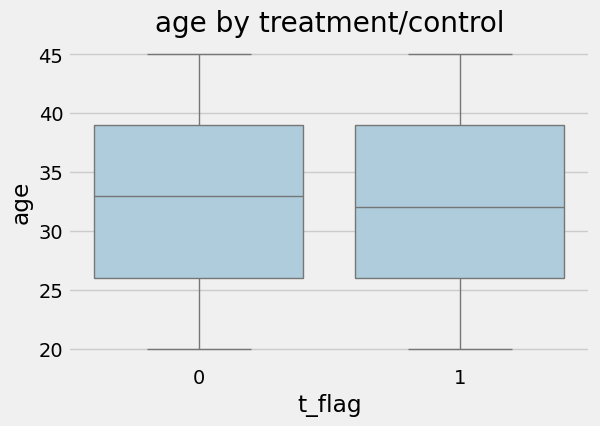

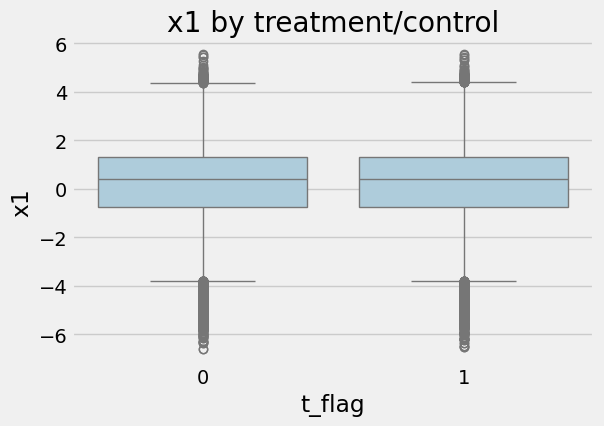

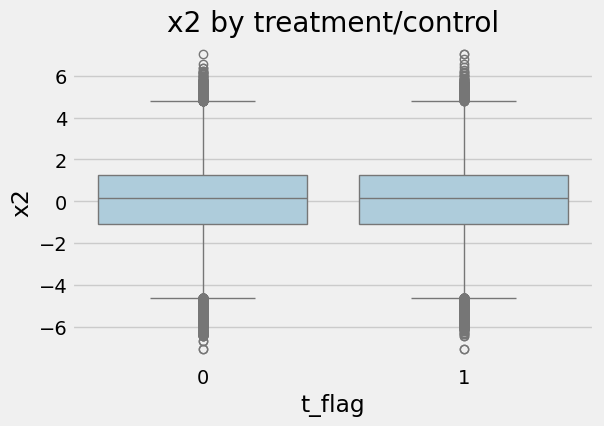

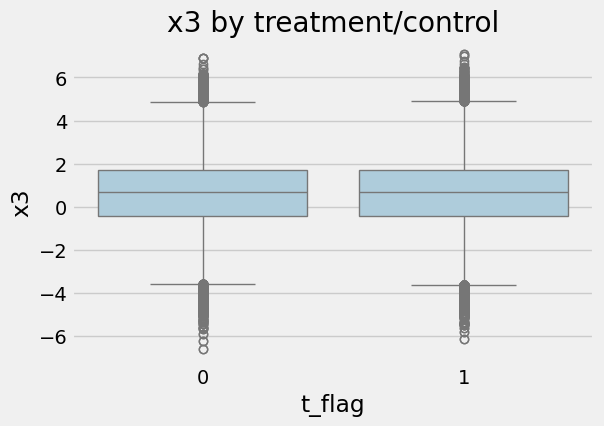

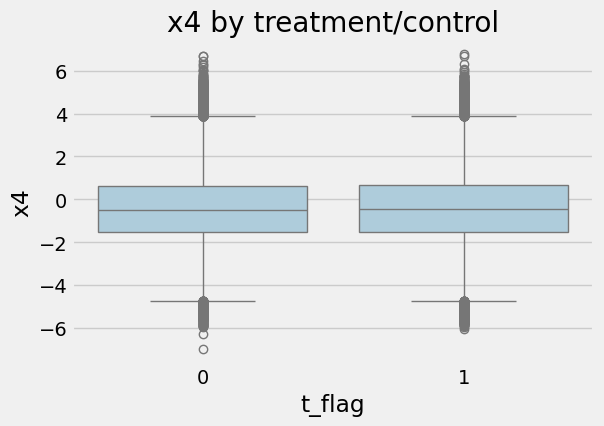

In [37]:
num_cols = ['age','x1','x2','x3','x4']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data_uplift, x='t_flag', y=col)
    plt.title(f'{col} by treatment/control')
    plt.show()

In [38]:
print('\nРаспределение city:')
print(
    pd.crosstab(data_uplift['city'], data_uplift['t_flag'], normalize='columns')
    .head(10)
)


Распределение city:
t_flag           0         1
city                        
Moscow    0.302250  0.331708
Smolensk  0.394619  0.333112
Ufa       0.303131  0.335181


In [39]:
bad_campaigns = campaign_check[
    (campaign_check['bad_group']) |
    (campaign_check['too_small'])
]

print('\nПлохие кампании:')
print(bad_campaigns)


Плохие кампании:
Empty DataFrame
Columns: [campaing_id, channel, control_n, treatment_n, bad_group, too_small]
Index: []


После присоединения клиентских агрегатов по ключу user_id и report_dt со сдвигом на 2 месяца удалось получить итоговый датасет для uplift-анализа без утечки таргета. Существенных проблем с джойном не наблюдается, агрегаты корректно сопоставились с клиентами.

В ходе Uplift EDA было проверено распределение таргета по каналам и группам. Во всех каналах доля целевого события в treatment группе отличается от control, что подтверждает наличие эффекта от коммуникаций. Наиболее высокий uplift наблюдается у канала push (~0.40), затем идут banner и other_ads (0.20). Канал sms показывает отрицательный uplift (-0.48), что говорит о негативном эффекте коммуникации.

Также была проведена проверка кампаний: все кампании содержат как контрольную, так и целевую группы, размеры групп сбалансированы, слишком маленьких кампаний нет. “Сломанные” кампании не обнаружены, что говорит о хорошем качестве данных.

В целом данные после присоединения агрегатов выглядят корректными и пригодными для построения uplift-моделей, при этом канал sms, вероятно, следует исключить или рассматривать отдельно из-за отрицательного эффекта.

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [42]:
model_data = data_uplift.copy()

if 'bad_campaigns' in globals() and len(bad_campaigns) > 0:
    model_data = model_data[~model_data['campaing_id'].isin(bad_campaigns['campaing_id'])].copy()

feature_cols = ['age', 'city', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
cat_cols = ['city']
num_cols = ['age', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

model_data = model_data.dropna(subset=['age', 'city']).copy()

print(model_data.shape)
print(model_data[['user_id', 'channel', 't_flag', 'target']].head())

(520000, 19)
   user_id channel  t_flag  target
0        1     sms       0       0
1        1    push       1       0
2        2    push       0       0
3        3    push       0       0
4        4    push       0       0


In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

In [53]:
def make_stratify_label(treatment, target):
    return treatment.astype(str) + '_' + target.astype(str)


def split_uplift_data(df, test_size=0.3, valid_size=0.5, random_state=42):
    """
    train / valid / test
    valid_size считается от holdout части
    """
    X = df[feature_cols].copy()
    y = df['target'].astype(int).copy()
    tr = df['t_flag'].astype(int).copy()

    strat = make_stratify_label(tr, y)

    X_train, X_temp, y_train, y_temp, tr_train, tr_temp = train_test_split(
        X, y, tr,
        test_size=test_size,
        random_state=random_state,
        stratify=strat
    )

    strat_temp = make_stratify_label(tr_temp, y_temp)

    X_valid, X_test, y_valid, y_test, tr_valid, tr_test = train_test_split(
        X_temp, y_temp, tr_temp,
        test_size=valid_size,
        random_state=random_state,
        stratify=strat_temp
    )

    return X_train, X_valid, X_test, y_train, y_valid, y_test, tr_train, tr_valid, tr_test


def qini_curve_manual(y_true, uplift, treatment):
    """
    Возвращает x, qini_curve
    """
    y_true = np.asarray(y_true).astype(int)
    uplift = np.asarray(uplift).reshape(-1)
    treatment = np.asarray(treatment).astype(int)

    order = np.argsort(-uplift)
    y_true = y_true[order]
    uplift = uplift[order]
    treatment = treatment[order]

    treated = (treatment == 1).astype(int)
    control = (treatment == 0).astype(int)

    y_treated = y_true * treated
    y_control = y_true * control

    cum_treated = np.cumsum(treated)
    cum_control = np.cumsum(control)

    cum_y_treated = np.cumsum(y_treated)
    cum_y_control = np.cumsum(y_control)

    ratio = np.divide(
        cum_treated,
        np.maximum(cum_control, 1),
        out=np.zeros_like(cum_treated, dtype=float),
        where=np.maximum(cum_control, 1) != 0
    )

    qini = cum_y_treated - cum_y_control * ratio

    x = np.arange(1, len(y_true) + 1) / len(y_true)
    x = np.insert(x, 0, 0)
    qini = np.insert(qini, 0, 0)

    return x, qini


def qini_auc_score_manual(y_true, uplift, treatment):
    x, qini = qini_curve_manual(y_true, uplift, treatment)

    baseline = np.linspace(0, qini[-1], len(qini))

    return np.trapezoid(qini - baseline, x)


def plot_qini_curve_manual(y_true, uplift, treatment, label=None):
    x, qini = qini_curve_manual(y_true, uplift, treatment)
    baseline = np.linspace(0, qini[-1], len(qini))

    plt.plot(x, qini, label=label)
    plt.plot(x, baseline, linestyle='--', color='gray', alpha=0.5)

In [46]:
def add_treatment_feature(X, treatment_values):
    X_new = X.copy()
    X_new['treatment_feature'] = treatment_values
    return X_new


def make_solo_pipeline(n_estimators=200, max_depth=6, min_samples_leaf=20):
    solo_num_cols = num_cols + ['treatment_feature']
    solo_cat_cols = cat_cols

    solo_preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]), solo_num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), solo_cat_cols)
        ]
    )

    pipe = Pipeline([
        ('prep', solo_preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
    return pipe


def fit_solo_model(X_train, y_train, tr_train, params):
    X_train_solo = add_treatment_feature(X_train, tr_train.values)
    model = make_solo_pipeline(**params)
    model.fit(X_train_solo, y_train)
    return model


def predict_solo_uplift(model, X):
    X_treat = add_treatment_feature(X, np.ones(len(X), dtype=int))
    X_ctrl = add_treatment_feature(X, np.zeros(len(X), dtype=int))

    p_treat = model.predict_proba(X_treat)[:, 1]
    p_ctrl = model.predict_proba(X_ctrl)[:, 1]

    return p_treat - p_ctrl

In [47]:
def make_two_model_base(n_estimators=200, max_depth=6, min_samples_leaf=20):
    base_pipe = Pipeline([
        ('prep', deepcopy(preprocessor)),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
    return base_pipe


def fit_two_model_calibrated(X_train, y_train, tr_train, params):
    X_tr = X_train.copy()
    y_tr = y_train.copy()
    tr_tr = tr_train.copy()

    X_t = X_tr[tr_tr == 1]
    y_t = y_tr[tr_tr == 1]

    X_c = X_tr[tr_tr == 0]
    y_c = y_tr[tr_tr == 0]

    model_t = CalibratedClassifierCV(
        estimator=make_two_model_base(**params),
        method='sigmoid',
        cv=3
    )
    model_c = CalibratedClassifierCV(
        estimator=make_two_model_base(**params),
        method='sigmoid',
        cv=3
    )

    model_t.fit(X_t, y_t)
    model_c.fit(X_c, y_c)

    return model_t, model_c


def predict_two_model_uplift(model_t, model_c, X):
    p_t = model_t.predict_proba(X)[:, 1]
    p_c = model_c.predict_proba(X)[:, 1]
    return p_t - p_c

In [48]:
def make_ct_pipeline(n_estimators=200, max_depth=6, min_samples_leaf=20):
    pipe = Pipeline([
        ('prep', deepcopy(preprocessor)),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
    return pipe


def fit_class_transformation(X_train, y_train, tr_train, params):
    z = (y_train.values * tr_train.values + (1 - y_train.values) * (1 - tr_train.values)).astype(int)
    model = make_ct_pipeline(**params)
    model.fit(X_train, z)
    return model


def predict_class_transformation_uplift(model, X):
    p = model.predict_proba(X)[:, 1]
    uplift = 2 * p - 1
    return uplift

In [55]:
def preprocess_dense(X_train, X_valid, X_test):
    prep = deepcopy(preprocessor)
    X_train_p = prep.fit_transform(X_train)
    X_valid_p = prep.transform(X_valid)
    X_test_p = prep.transform(X_test)
    return prep, X_train_p, X_valid_p, X_test_p

def fit_uplift_rf(X_train, y_train, tr_train, X_valid, params):
    prep, X_train_p, X_valid_p, _ = preprocess_dense(X_train, X_valid, X_valid)

    treatment_train = np.where(tr_train.values == 1, 'treatment', 'control')

    model = UpliftRandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=RANDOM_STATE,
        control_name='control'
    )

    model.fit(
        X=X_train_p,
        treatment=treatment_train,
        y=y_train.values
    )

    return prep, model

def predict_uplift_rf(prep, model, X):
    X_p = prep.transform(X)
    uplift_pred = model.predict(X_p)

    uplift_pred = np.asarray(uplift_pred)

    if uplift_pred.ndim > 1:
        uplift_pred = uplift_pred.reshape(-1)

    return uplift_pred

In [57]:
solo_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'min_samples_leaf': [50]
}

two_model_grid = {
    'n_estimators': [100],
    'max_depth': [6],
    'min_samples_leaf': [50]
}

ct_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'min_samples_leaf': [50]
}

urf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'min_samples_leaf': [100]
}

In [51]:
def fit_and_eval_channel(df_channel, channel_name):
    X_train, X_valid, X_test, y_train, y_valid, y_test, tr_train, tr_valid, tr_test = split_uplift_data(
        df_channel, test_size=0.3, valid_size=0.5, random_state=RANDOM_STATE
    )

    results = []
    models_pack = {}

    # ===== SoloModel =====
    best_solo_model = None
    best_solo_params = None
    best_solo_valid = -np.inf

    for params in ParameterGrid(solo_grid):
        model = fit_solo_model(X_train, y_train, tr_train, params)
        uplift_pred_valid = predict_solo_uplift(model, X_valid)
        score_valid = qini_auc_score_manual(y_valid, uplift_pred_valid, tr_valid)

        if score_valid > best_solo_valid:
            best_solo_valid = score_valid
            best_solo_model = model
            best_solo_params = params

    uplift_pred_test = predict_solo_uplift(best_solo_model, X_test)
    solo_test_qini = qini_auc_score_manual(y_test, uplift_pred_test, tr_test)

    results.append({
        'channel': channel_name,
        'model': 'SoloModel',
        'valid_qini': best_solo_valid,
        'test_qini': solo_test_qini,
        'best_params': best_solo_params
    })

    models_pack['SoloModel'] = {
        'model': best_solo_model,
        'X_test': X_test,
        'y_test': y_test,
        'tr_test': tr_test,
        'uplift_pred': uplift_pred_test
    }

    # ===== TwoModel + calibration =====
    best_tm = None
    best_tm_params = None
    best_tm_valid = -np.inf

    for params in ParameterGrid(two_model_grid):
        model_t, model_c = fit_two_model_calibrated(X_train, y_train, tr_train, params)
        uplift_pred_valid = predict_two_model_uplift(model_t, model_c, X_valid)
        score_valid = qini_auc_score_manual(y_valid, uplift_pred_valid, tr_valid)

        if score_valid > best_tm_valid:
            best_tm_valid = score_valid
            best_tm = (model_t, model_c)
            best_tm_params = params

    model_t, model_c = best_tm
    uplift_pred_test = predict_two_model_uplift(model_t, model_c, X_test)
    tm_test_qini = qini_auc_score_manual(y_test, uplift_pred_test, tr_test)

    results.append({
        'channel': channel_name,
        'model': 'TwoModelCalibrated',
        'valid_qini': best_tm_valid,
        'test_qini': tm_test_qini,
        'best_params': best_tm_params
    })

    models_pack['TwoModelCalibrated'] = {
        'model_t': model_t,
        'model_c': model_c,
        'X_test': X_test,
        'y_test': y_test,
        'tr_test': tr_test,
        'uplift_pred': uplift_pred_test
    }

    # ===== ClassTransformation =====
    best_ct_model = None
    best_ct_params = None
    best_ct_valid = -np.inf

    for params in ParameterGrid(ct_grid):
        model = fit_class_transformation(X_train, y_train, tr_train, params)
        uplift_pred_valid = predict_class_transformation_uplift(model, X_valid)
        score_valid = qini_auc_score_manual(y_valid, uplift_pred_valid, tr_valid)

        if score_valid > best_ct_valid:
            best_ct_valid = score_valid
            best_ct_model = model
            best_ct_params = params

    uplift_pred_test = predict_class_transformation_uplift(best_ct_model, X_test)
    ct_test_qini = qini_auc_score_manual(y_test, uplift_pred_test, tr_test)

    results.append({
        'channel': channel_name,
        'model': 'ClassTransformation',
        'valid_qini': best_ct_valid,
        'test_qini': ct_test_qini,
        'best_params': best_ct_params
    })

    models_pack['ClassTransformation'] = {
        'model': best_ct_model,
        'X_test': X_test,
        'y_test': y_test,
        'tr_test': tr_test,
        'uplift_pred': uplift_pred_test
    }

    # ===== UpliftRandomForest =====
    best_urf_bundle = None
    best_urf_params = None
    best_urf_valid = -np.inf

    for params in ParameterGrid(urf_grid):
        prep, urf_model = fit_uplift_rf(X_train, y_train, tr_train, X_valid, params)
        uplift_pred_valid = predict_uplift_rf(prep, urf_model, X_valid)
        score_valid = qini_auc_score_manual(y_valid, uplift_pred_valid, tr_valid)

        if score_valid > best_urf_valid:
            best_urf_valid = score_valid
            best_urf_bundle = (prep, urf_model)
            best_urf_params = params

    prep, urf_model = best_urf_bundle
    uplift_pred_test = predict_uplift_rf(prep, urf_model, X_test)
    urf_test_qini = qini_auc_score_manual(y_test, uplift_pred_test, tr_test)

    results.append({
        'channel': channel_name,
        'model': 'UpliftRandomForest',
        'valid_qini': best_urf_valid,
        'test_qini': urf_test_qini,
        'best_params': best_urf_params
    })

    models_pack['UpliftRandomForest'] = {
        'prep': prep,
        'model': urf_model,
        'X_test': X_test,
        'y_test': y_test,
        'tr_test': tr_test,
        'uplift_pred': uplift_pred_test
    }

    return pd.DataFrame(results), models_pack

In [58]:
channel_results = []
channel_models = {}

for channel_name in sorted(model_data['channel'].unique()):
    print(f'===== CHANNEL: {channel_name} =====')
    df_channel = model_data[model_data['channel'] == channel_name].copy()

    res_df, models_pack = fit_and_eval_channel(df_channel, channel_name)

    channel_results.append(res_df)
    channel_models[channel_name] = models_pack

results_df = pd.concat(channel_results, ignore_index=True)
results_df

===== CHANNEL: banner =====
===== CHANNEL: other_ads =====
===== CHANNEL: push =====
===== CHANNEL: sms =====


,channel,model,valid_qini,test_qini,best_params
0,banner,SoloModel,684.233785,754.956546,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
1,banner,TwoModelCalibrated,684.651455,723.511203,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
2,banner,ClassTransformation,697.116751,748.087843,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
3,banner,UpliftRandomForest,698.488580,745.247258,"{'max_depth': 6, 'min_samples_leaf': 100, 'n_e..."
4,other_ads,SoloModel,695.222217,699.176594,"{'max_depth': 4, 'min_samples_leaf': 50, 'n_es..."
5,other_ads,TwoModelCalibrated,704.243873,711.438381,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
6,other_ads,ClassTransformation,2052.857043,2059.393692,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
7,other_ads,UpliftRandomForest,720.788677,737.786015,"{'max_depth': 6, 'min_samples_leaf': 100, 'n_e..."
8,push,SoloModel,1413.695558,1393.125051,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
9,push,TwoModelCalibrated,1401.389732,1402.137904,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."


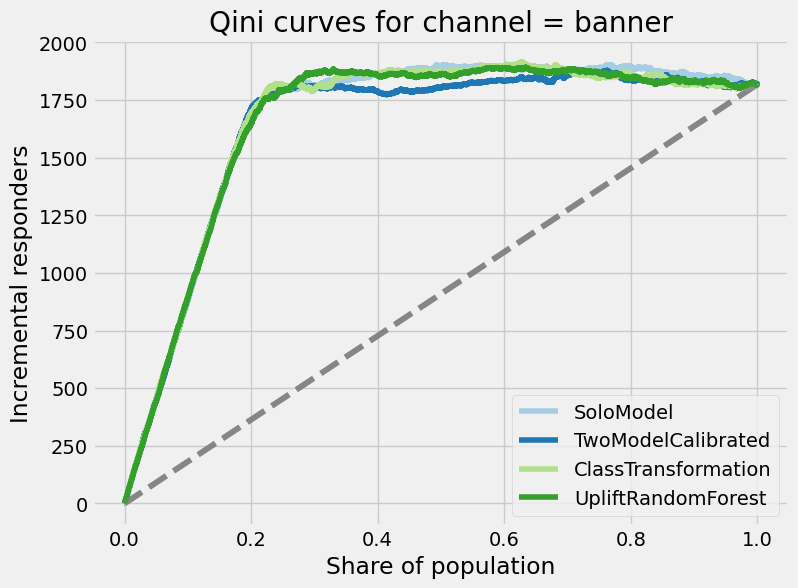

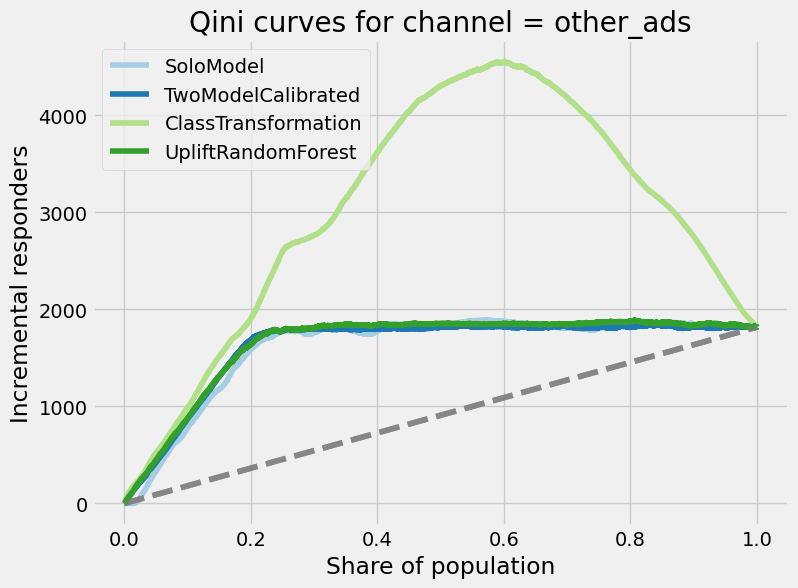

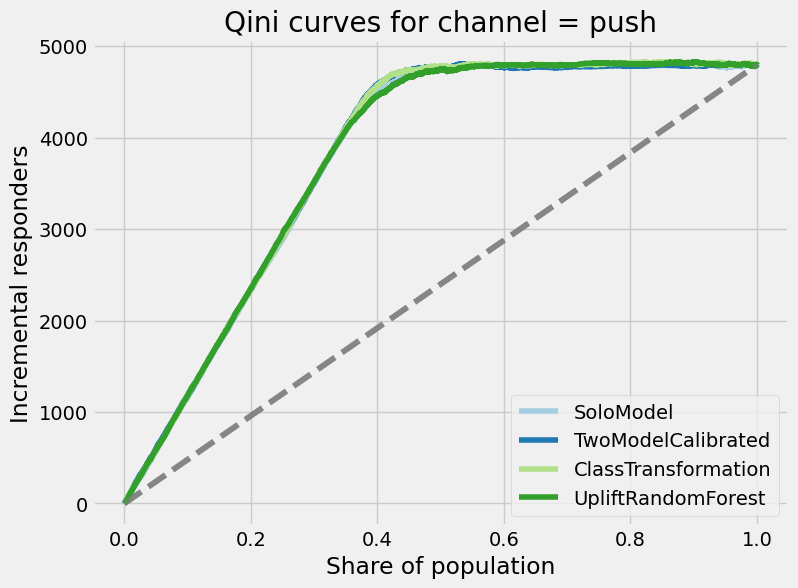

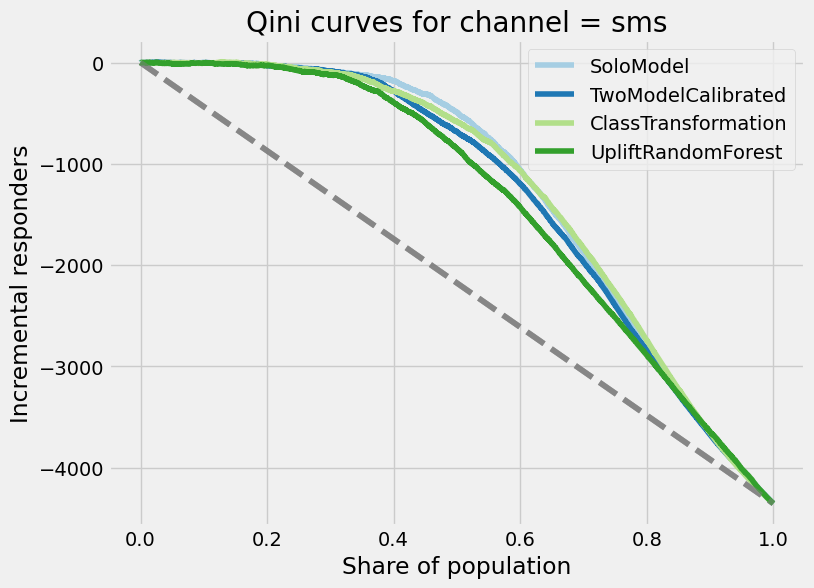

In [59]:
for channel_name, models_pack in channel_models.items():
    plt.figure(figsize=(8, 6))

    for model_name, pack in models_pack.items():
        y_test = pack['y_test']
        tr_test = pack['tr_test']
        uplift_pred = pack['uplift_pred']

        plot_qini_curve_manual(
            y_true=y_test,
            uplift=uplift_pred,
            treatment=tr_test,
            label=f'{model_name}'
        )

    plt.title(f'Qini curves for channel = {channel_name}')
    plt.xlabel('Share of population')
    plt.ylabel('Incremental responders')
    plt.legend()
    plt.show()

In [60]:
best_models = (
    results_df.sort_values(['channel', 'test_qini'], ascending=[True, False])
    .groupby('channel')
    .head(1)
    .reset_index(drop=True)
)

best_models

,channel,model,valid_qini,test_qini,best_params
0,banner,SoloModel,684.233785,754.956546,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
1,other_ads,ClassTransformation,2052.857043,2059.393692,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
2,push,ClassTransformation,1414.330696,1409.930672,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."
3,sms,SoloModel,960.048447,943.891145,"{'max_depth': 6, 'min_samples_leaf': 50, 'n_es..."


In [61]:
print(results_df.sort_values(['channel', 'test_qini'], ascending=[True, False]))

      channel                model   valid_qini    test_qini  \
0      banner            SoloModel   684.233785   754.956546   
2      banner  ClassTransformation   697.116751   748.087843   
3      banner   UpliftRandomForest   698.488580   745.247258   
1      banner   TwoModelCalibrated   684.651455   723.511203   
6   other_ads  ClassTransformation  2052.857043  2059.393692   
7   other_ads   UpliftRandomForest   720.788677   737.786015   
5   other_ads   TwoModelCalibrated   704.243873   711.438381   
4   other_ads            SoloModel   695.222217   699.176594   
10       push  ClassTransformation  1414.330696  1409.930672   
9        push   TwoModelCalibrated  1401.389732  1402.137904   
11       push   UpliftRandomForest  1407.314374  1398.115398   
8        push            SoloModel  1413.695558  1393.125051   
12        sms            SoloModel   960.048447   943.891145   
14        sms  ClassTransformation   950.866910   936.934603   
13        sms   TwoModelCalibrated   901

Построение uplift-моделей показало, что качество моделей существенно зависит от канала коммуникации. Для оценки использовался qini score, который отражает способность модели правильно ранжировать клиентов по величине uplift.

Наилучшие результаты по каналам получились следующими. Для канала banner лучшей моделью оказался SoloModel с qini score около 755 на тесте, при этом остальные модели показали сопоставимое, но немного худшее качество. Для канала other_ads наилучший результат продемонстрировала модель ClassTransformation с существенно более высоким qini score (~2059), что говорит о хорошем разделении клиентов по эффекту воздействия. Для канала push также лучшей оказалась ClassTransformation с qini score около 1410, при этом остальные модели показали близкие, но немного худшие результаты. Для канала sms наилучший результат снова показал SoloModel (~944), тогда как более сложные модели не дали прироста качества.

Можно заметить, что более сложные модели (TwoModelCalibrated и UpliftRandomForest) не всегда дают преимущество. В частности, UpliftRandomForest во всех каналах показал более низкое качество по сравнению с более простыми подходами. Это может быть связано с особенностями данных и ограниченным количеством информации для обучения сложных моделей.

ClassTransformation показал себя особенно хорошо для каналов с сильным положительным uplift (push и other_ads), тогда как SoloModel оказался более устойчивым для каналов с более слабым или нестабильным эффектом (banner и sms).

Графики qini curve подтверждают полученные результаты: лучшие модели имеют более высокую кривую и быстрее накапливают прирост целевого действия при отборе клиентов.

В целом можно сделать вывод, что использование uplift-моделей действительно позволяет эффективно ранжировать клиентов по ожидаемому эффекту коммуникации, однако выбор конкретного алгоритма зависит от канала и структуры данных.

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [63]:
aggs['report_dt'] = pd.to_datetime(aggs['report_dt'])
target_report_dt = pd.Timestamp('2025-01-31')
scoring_data = aggs[aggs['report_dt'] == target_report_dt].copy()
X_scoring = scoring_data[feature_cols].copy()

uplift_preds = pd.DataFrame({
    'user_id': scoring_data['user_id'],
    'report_dt': scoring_data['report_dt']
})

for _, row in best_models.iterrows():
    channel = row['channel']
    model_name = row['model']

    print(f'Predicting for channel: {channel} with model: {model_name}')

    pack = channel_models[channel][model_name]

    if model_name == 'SoloModel':
        uplift = predict_solo_uplift(pack['model'], X_scoring)

    elif model_name == 'TwoModelCalibrated':
        uplift = predict_two_model_uplift(pack['model_t'], pack['model_c'], X_scoring)

    elif model_name == 'ClassTransformation':
        uplift = predict_class_transformation_uplift(pack['model'], X_scoring)

    elif model_name == 'UpliftRandomForest':
        uplift = predict_uplift_rf(pack['prep'], pack['model'], X_scoring)

    uplift_preds[channel] = uplift

channels = best_models['channel'].unique()

uplift_values = uplift_preds[channels].values

best_channel_idx = np.argmax(uplift_values, axis=1)
best_uplift = np.max(uplift_values, axis=1)

best_channel = [channels[i] for i in best_channel_idx]

final_channel = [
    ch if up > 0 else 'no_comm'
    for ch, up in zip(best_channel, best_uplift)
]

final_uplift = [
    up if up > 0 else 0
    for up in best_uplift
]

final_df = pd.DataFrame({
    'user_id': scoring_data['user_id'],
    'report_dt': scoring_data['report_dt'],
    'channel': final_channel,
    'uplift': final_uplift
})

final_df.head()

Predicting for channel: banner with model: SoloModel
Predicting for channel: other_ads with model: ClassTransformation
Predicting for channel: push with model: ClassTransformation
Predicting for channel: sms with model: SoloModel


,user_id,report_dt,channel,uplift
0,1066338,2025-01-31,other_ads,0.454357
19,25872,2025-01-31,other_ads,0.499736
48,4107442,2025-01-31,other_ads,0.434485
66,2047420,2025-01-31,banner,0.097686
67,1120643,2025-01-31,other_ads,0.438964


In [64]:
print(final_df['channel'].value_counts())
print(final_df['uplift'].describe())

channel
other_ads    262549
push         150508
banner        46784
no_comm         159
Name: count, dtype: int64
count    460000.000000
mean          0.458997
std           0.205323
min           0.000000
25%           0.331977
50%           0.456863
75%           0.607076
max           0.906814
Name: uplift, dtype: float64


#### Б)

Анализ результатов скоринга показал, что наиболее эффективным каналом коммуникации является other_ads — он был выбран для большинства клиентов (262 тыс.), что говорит о высокой ожидаемой эффективности данного канала. На втором месте находится канал push (150 тыс.), который также показывает значительный положительный uplift.

Канал banner используется существенно реже (~47 тыс.), что указывает на его более ограниченную эффективность по сравнению с другими каналами. Канал sms практически не используется моделью, что согласуется с предыдущим анализом, где он демонстрировал отрицательный uplift.

Доля клиентов, для которых не рекомендуется отправлять коммуникацию (no_comm), крайне мала (159 человек), что говорит о том, что для подавляющего большинства клиентов ожидается положительный эффект от взаимодействия.

Таким образом, приоритетными каналами коммуникации являются other_ads и push, в то время как banner играет вспомогательную роль, а sms не рекомендуется к использованию.

#### В)

В ходе работы была решена задача выбора оптимального канала коммуникации для клиентов с использованием uplift-моделирования. На первом этапе был корректно сформирован таргет с учетом временных окон и различий между целевой и контрольной группами, что позволило избежать искажения результатов.

Далее были присоединены клиентские агрегаты с учетом лага в два месяца, что исключило утечку таргета и обеспечило корректность обучения моделей. Проведенный анализ показал, что различные каналы коммуникации имеют разную эффективность, при этом канал sms оказался неэффективным.

На этапе моделирования были реализованы несколько подходов (SoloModel, TwoModel с калибровкой, ClassTransformation и UpliftRandomForest), и проведен подбор гиперпараметров. Лучшие результаты показали более простые модели, в частности SoloModel и ClassTransformation, которые обеспечили наибольший qini score.

На основе обученных моделей был выполнен скоринг клиентов, и для каждого клиента был выбран канал с максимальным положительным uplift. Если ожидаемый uplift был отрицательным или равен нулю, коммуникация не отправлялась.

Результаты показали, что наиболее эффективными каналами являются other_ads и push, которые позволяют максимизировать прирост вероятности покупки. Таким образом, построенная система позволяет персонализировать маркетинговые коммуникации и повысить их эффективность за счет таргетирования только тех клиентов, для которых ожидается положительный эффект.